"""
Notebook 03

Medical Preprocessing Pipeline

Project:
Lung AI Platform

Author:
Rira-Cyber
"""

In [1]:
import numpy as np
import sys
import matplotlib.pyplot as plt
from pathlib import Path
import pydicom

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(project_root)

e:\My codes\Medical AI\lung-ai-platform


In [2]:
import backend
print("Backend imported successfully!")

Backend imported successfully!


In [3]:
from backend.medical.ct_volume import CTVolume

In [4]:
dicom_folder = Path(
    r"E:\My codes\Medical AI\lung-ai-platform\data\raw\lidc_idri\LIDC-IDRI-0001\2000-01-01-30178\3000566-03192"
)

ct = CTVolume(dicom_folder)

print(ct)

CTVolume
-------------------------
Slices          : 133
Rows            : 512
Columns         : 512
Pixel Spacing   : [0.703125, 0.703125]
Slice Thickness : 2.5 mm


In [5]:

dicom_files = list(dicom_folder.glob("*.dcm"))

print(len(dicom_files))

for f in dicom_files[:5]:
    print(f.name)

133
02d4eaa3-2c40-4782-a86d-1465065ce2f6.dcm
05b232bb-e671-41cd-9cee-0f390f2652ef.dcm
061a42aa-5116-4bc7-8ebd-f444249d05e9.dcm
06a7bc66-9c31-4819-9010-ac87623ff69e.dcm
0a56ff89-83ec-4b15-a27f-78786dbd8f01.dcm


In [6]:
def quality_check(ct):

    print("=" * 60)
    print("CT QUALITY REPORT")
    print("=" * 60)

    print(f"Shape             : {ct.volume.shape}")
    print(f"Pixel Spacing     : {ct.pixel_spacing}")
    print(f"Slice Thickness   : {ct.slice_thickness}")

    print(f"Pixel Min         : {ct.volume.min()}")
    print(f"Pixel Max         : {ct.volume.max()}")

    print("=" * 60)

In [7]:
quality_check(ct)

CT QUALITY REPORT
Shape             : (133, 512, 512)
Pixel Spacing     : [0.703125, 0.703125]
Slice Thickness   : 2.5
Pixel Min         : -1024
Pixel Max         : 4095


In [8]:
from backend.medical.preprocessor import CTPreprocessor

preprocessor = CTPreprocessor()

hu_volume = preprocessor.to_hu(ct)

In [9]:
print("Shape:", hu_volume.shape)
print("Min :", hu_volume.min())
print("Max :", hu_volume.max())

Shape: (133, 512, 512)
Min : -2048.0
Max : 3071.0


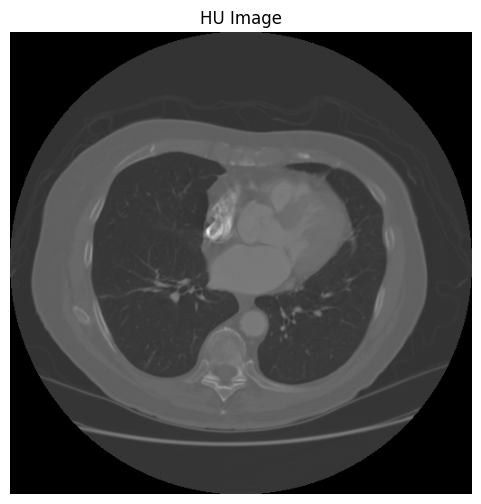

In [10]:
slice_idx = hu_volume.shape[0] // 2

plt.figure(figsize=(6,6))
plt.imshow(hu_volume[slice_idx], cmap="gray")
plt.title("HU Image")
plt.axis("off")
plt.show()

In [11]:
clipped = preprocessor.clip_hu(hu_volume)

print(clipped.min())
print(clipped.max())

-1000.0
400.0


In [12]:
lung_window = preprocessor.window(
    clipped
)

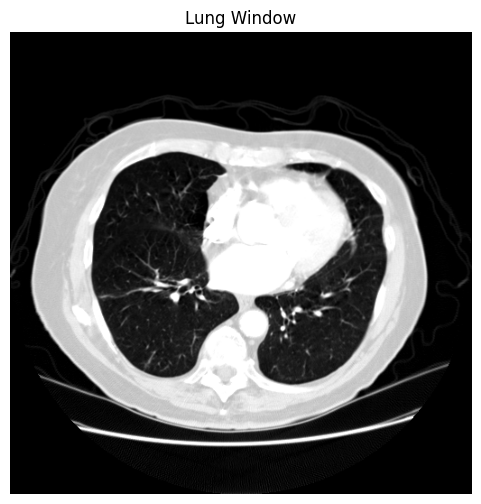

In [13]:
slice_idx = lung_window.shape[0] // 2

plt.figure(figsize=(6,6))

plt.imshow(
    lung_window[slice_idx],
    cmap="gray"
)

plt.axis("off")

plt.title("Lung Window")

plt.show()

In [14]:
lung = preprocessor.window(
    hu_volume,
    -600,
    1500
)

In [15]:
soft = preprocessor.window(
    hu_volume,
    40,
    400
)

In [16]:
bone = preprocessor.window(
    hu_volume,
    300,
    1500
)

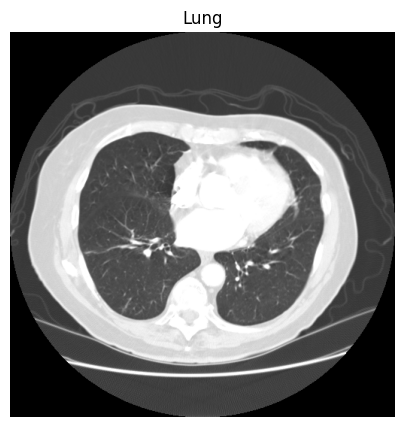

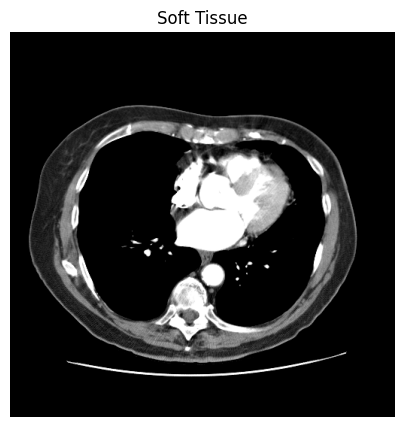

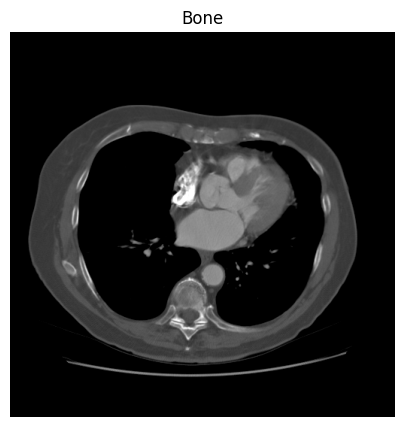

In [17]:
windows = {
    "Lung": lung,
    "Soft Tissue": soft,
    "Bone": bone
}

slice_idx = hu_volume.shape[0] // 2

for name, img in windows.items():

    plt.figure(figsize=(5,5))

    plt.imshow(
        img[slice_idx],
        cmap="gray"
    )

    plt.title(name)

    plt.axis("off")

    plt.show()